In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
import numpy as np
%matplotlib inline


In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars = []
for i in range(ord('a'), ord('z') + 1):
    print(chr(i), end=' ')
    chars.append(f"{chr(i)}")
stoi={}
stoi['.'] = 0
stoi|= {ch: i+1  for i, ch in enumerate(chars)}
itos = {i:ch for (ch, i) in stoi.items()}

a b c d e f g h i j k l m n o p q r s t u v w x y z 

In [67]:
# build the dataset
# lets define block_size = k, the number of characters that would feed into this neural network.
block_size = 8

def build_dataset(words):
    # Rolling window dataset: 
    context = [stoi['.']] *  block_size
    X, Y  = [], []
    
    for w in words[:]:
        chrs = list(w) + ['.']
        for ch in chrs:
            #print(context, ch)
            X.append(context)
            Y.append(stoi[ch])
            context = context[1:] + [stoi[ch]]
    # for x, y in zip(X, Y):
    #     print(''.join([itos[k] for k in x]), itos[y])
    
    Xt, Yt = torch.tensor(X), torch.tensor(Y)
    print(Xt.shape, Yt.shape)
    return Xt, Yt

# random shuffle
import random
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtrain, Ytrain = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182517, 8]) torch.Size([182517])
torch.Size([22830, 8]) torch.Size([22830])
torch.Size([22799, 8]) torch.Size([22799])


In [17]:
for i,j in zip(Xtrain[:20], Ytrain[:20]):
    print(''.join([itos[k.item()] for k in i]), "----->", itos[j.item()])

... -----> d
..d -----> r
.dr -----> e
dre -----> a
rea -----> m
eam -----> .
am. -----> y
m.y -----> e
.ye -----> z
yez -----> e
eze -----> n
zen -----> .
en. -----> d
n.d -----> e
.de -----> v
dev -----> a
eva -----> n
van -----> t
ant -----> e
nte -----> .


In [115]:
# the torch friendly class-based OO stack
# Build a linear layer similar to pytorch. they use pytorch.tensor to hold values. 
# g = torch.Generator().manual_seed(2147483647)
torch.manual_seed(42)

class Linear:

    def __init__(self, fan_in: int , fan_out: int, bias=True): 
        self.weight = torch.randn((fan_in, fan_out)) / (fan_in ** 0.5)
        self.bias = torch.randn(fan_out) if bias else None

    def debug(self):
        print(f"weight({self.weight.shape}) and bias ({self.bias.shape})")

    def __call__(self, x):
        t = x @ self.weight
        # "is not" checks object memory
        if self.bias is not None:
            t += self.bias
        self.out = t
        return self.out

    def __repr__(self):
        return f"Linear:({self.weight.shape}) / ({None if self.bias is None else self.bias.shape})"

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class Tanh():
        
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
        
    def parameters(self):
        return []
        
    def __repr__(self):
        return "Tanh()"

# BatchNorm has memory for parameter per neuron since we might want to move each neuron differently towards
# the edges of the activation function.
class BatchNorm1d:
    def __init__(self, layer_fanout, eps=1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = 0.1
        self.training = True
        self.gamma = torch.ones((1, layer_fanout))
        self.beta = torch.zeros((1, layer_fanout))

        self.running_mean = torch.zeros((1, layer_fanout))
        self.running_var = torch.ones((1, layer_fanout))
        

    def __call__(self, x):
        # (x - mean)/ std
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
                
            mean = x.mean(dim, keepdims=True)
            var = x.var(dim, keepdims=True)
        else:
            mean = self.running_mean
            var = self.running_var
            
        tmp_out = (x - mean) / torch.sqrt(var + self.eps)

        self.out = tmp_out * self.gamma + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1.0 - self.momentum) * self.running_mean + self.momentum * mean
                self.running_var = (1.0 - self.momentum) * self.running_var + self.momentum * var
        
        return self.out

    def __repr__(self):
        return f"BN(gamma({self.gamma.shape}), beta({self.beta.shape})"
        
    def parameters(self):
        return [self.gamma, self.beta]


class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.emb_table = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, x):
        self.out = self.emb_table[x]
        return self.out

    def parameters(self):
        return [self.emb_table]


class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    def parameters(self):
        return []


# n is the mini-block size for the conv sweep.
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n
        
    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(x.shape[0], T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(dim=1)
        self.out = x
        return self.out
        
    def parameters(self):
        return []


class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            #print(f"layer {l}")
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for l in self.layers for p in l.parameters()]
        

In [100]:
# specify the network
# Embedding lookup table C

# hyperparams
vocab_size = len(itos)
n_embed = 10
n_hidden = 200

# C = torch.randn((vocab_size, n_embed))

layers = [
    Embedding(vocab_size, n_embed), 
    Flatten(), 
    Linear(block_size*n_embed, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]
model = Sequential(layers)

# scale layer.weight by an appropriate factor.
with torch.no_grad():
    last_layer = layers[-1]
    if hasattr(last_layer, "weight"):
        last_layer.weight *= 0.1
    else:
        if hasattr(last_layer, "gamma"):
            last_layer.gamma *= 0.1
    for layer in layers:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

# set req grad for all parameters

parameters = [p for l in layers for p in l.parameters() ]
print(f"Number of parametes: {sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad = True

Number of parametes: 22097


In [38]:
# TODO: Add the sequential layer and clean up the code.
# Get to a validation loss of aroun 2.105
# FlattenConsecutive

In [69]:
# forward, backward pass 
# Forward pass, backward pass and update (grad)

lossi = []
stepi= []
lri = []
batch_size = 32
max_steps = 200000
ud = []

input_vector_size = block_size * n_embed
for i in range(max_steps):
    ix = torch.randint(0, Xtrain.shape[0], (batch_size, ))
    Xb, Yb = Xtrain[ix], Ytrain[ix]
    
    logits=model(Xb)
    loss = torch.nn.functional.cross_entropy(logits, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
        
    # zero grad
    
    for p in parameters:
        p.grad = None
        
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    # update the weights
    for p in parameters:
        p.data += (-lr * p.grad)
    lossi.append(loss)
    stepi.append(i)

    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    # if i > 1:
    #     break  # for debug only.


      0/ 200000: 4.1879
  10000/ 200000: 2.3616
  20000/ 200000: 1.9998
  30000/ 200000: 2.3403
  40000/ 200000: 2.4611
  50000/ 200000: 1.6630
  60000/ 200000: 1.9388
  70000/ 200000: 1.8520
  80000/ 200000: 1.8142
  90000/ 200000: 1.9710
 100000/ 200000: 2.1461
 110000/ 200000: 1.8240
 120000/ 200000: 1.8216
 130000/ 200000: 2.0293
 140000/ 200000: 2.4558
 150000/ 200000: 2.2911
 160000/ 200000: 1.8322
 170000/ 200000: 2.0902
 180000/ 200000: 1.9817
 190000/ 200000: 1.6633


In [116]:
# put layers into eval mode (for the batch norm layer specifically)
for layer in model.layers:
    layer.training = False

In [117]:
@torch.no_grad()
def split_loss(split):
    x, y = {
    'train': (Xtrain, Ytrain),
    'val': (Xdev, Ydev),
    'test': (Xtest, Ytest),
       }[split]
    #emb = C[x] # (N, block_size, n_embd)
      # This is cool, wherever we have -1, its inferred from other dimensions.
    #embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    # out = embcat
    # for l in layers:
    #     out = l(out)
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.6565327644348145
val 2.6838808059692383


## Loss tracker
- Original 3 character context, 200 hidden neurons, 12k params: train 2.051     val 2.104
- character context = 8, 200 hidden neurons, 22k params:        train 2.0137     val 2.1079
- char context = 8, 2 flatten each layer conv. 170k params; train 1.7273797988891602  val 2.0735373497009277


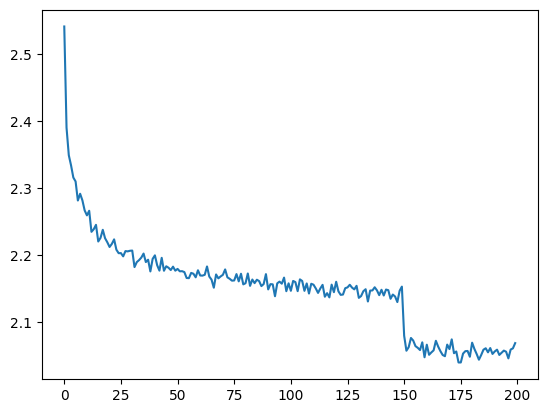

In [62]:

plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [66]:
# sample from the model: 

def sample():
    out = []
    context = [0] * block_size
    
    while True:
        x = model(torch.tensor([context]))
        x.shape    
        
        probs = F.softmax(x, dim=1)
        y = torch.multinomial(probs, num_samples=1).item()
        #print(itos[y])
        out.append(itos[y])
        context = context[1:] + [y]
        #print(itos[y])
        if y == 0:
            break
    
    sample = ''.join(out)
    print(sample)
    return sample

for _ in range(20):
     sample()

heymelis.
kersh.
hayli.
zelyn.
ozmaizlyn.
france.
casafwen.
calyanna.
embally.
sante.
phey.
aryan.
kal.
deviana.
heron.
kaloneh.
emorgeana.
hum.
caal.
hoxxon.
oluwan.


'oluwan.'

In [ ]:
# what does the process of development of a deep neural network looks like ?
# Create a small example trainable in, say 30-60 minutes on a collab machine, and demonstrate experimentation methods
# to create a harness to experiment with populations of hyper-parameter values to narrow those down using a validation dataset before
# doing a full-training with them. 

In [ ]:
# Can learning rate be smarter ? look at the jump in the graph.
# ability to edit the model
# experiment with visualizing activations.

# model 2: with hierarchical convolutional layers

In [77]:
ix = torch.randint(0, Xtrain.shape[0], (4,))

In [78]:
ix.shape

torch.Size([4])

In [79]:
Xtrain[ix]

tensor([[ 0, 20, 18,  5, 13,  5, 12,  0],
        [25, 14,  0,  4,  5, 13, 15, 14],
        [ 8, 25, 12,  1, 14,  4,  0,  1],
        [19,  1, 12,  5, 14,  5,  0,  1]])

In [82]:
z = torch.randn(4, 5, 2, 80) @ torch.randn(80, 200) + torch.randn(200)
z.shape

torch.Size([4, 5, 2, 200])

In [95]:
a1 = torch.arange(10).view(2, 5)
a1

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [96]:
b1 = torch.arange(20,30).view(2, 5)
b1

tensor([[20, 21, 22, 23, 24],
        [25, 26, 27, 28, 29]])

In [97]:
torch.cat((a1, b1),dim=1)

tensor([[ 0,  1,  2,  3,  4, 20, 21, 22, 23, 24],
        [ 5,  6,  7,  8,  9, 25, 26, 27, 28, 29]])

In [125]:
# MODEL CONV ----------------

# specify the network
# Embedding lookup table C

# hyperparams
vocab_size = len(itos)
n_embed = 24
n_hidden = 128

# C = torch.randn((vocab_size, n_embed))

block_size = 8
model2 = Sequential([
    Embedding(vocab_size, n_embed), 
    FlattenConsecutive(2), 
    Linear(2*n_embed, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),
    Linear(2*n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),
    Linear(2*n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

def normalize_layer_weight(model):
    # scale layer.weight by an appropriate factor.
    with torch.no_grad():
        last_layer = model.layers[-1]
        if hasattr(last_layer, "weight"):
            last_layer.weight *= 0.1
        else:
            if hasattr(last_layer, "gamma"):
                last_layer.gamma *= 0.1
        for layer in layers:
            if isinstance(layer, Linear):
                layer.weight *= 5/3

normalize_layer_weight(model2)

# set req grad for all parameters

parameters = model2.parameters()
print(f"Number of parametes: {sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad = True

Number of parametes: 76579


In [127]:
# MODEL 2: forward, backward pass 
# Forward pass, backward pass and update (grad)

lossi = []
stepi= []
lri = []
batch_size = 32
max_steps = 200000
ud = []

input_vector_size = block_size * n_embed
for i in range(max_steps):
    ix = torch.randint(0, Xtrain.shape[0], (batch_size, ))
    Xb, Yb = Xtrain[ix], Ytrain[ix]
    
    logits=model2(Xb)
    loss = torch.nn.functional.cross_entropy(logits, Yb)

    # backward pass
    for layer in model2.layers:
        layer.out.retain_grad()
        
    # zero grad
    
    for p in parameters:
        p.grad = None
        
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    # update the weights
    for p in parameters:
        p.data += (-lr * p.grad)
    lossi.append(loss)
    stepi.append(i)

    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    # if i > 1:
    #     break  # for debug only.


      0/ 200000: 3.3420
  10000/ 200000: 1.8650
  20000/ 200000: 1.8716
  30000/ 200000: 2.0301
  40000/ 200000: 1.6957
  50000/ 200000: 1.7885
  60000/ 200000: 2.0474
  70000/ 200000: 2.2039
  80000/ 200000: 2.5903
  90000/ 200000: 1.7664
 100000/ 200000: 2.0984
 110000/ 200000: 1.7904
 120000/ 200000: 2.2935
 130000/ 200000: 2.1548
 140000/ 200000: 1.7979
 150000/ 200000: 2.1541
 160000/ 200000: 2.1022
 170000/ 200000: 2.1700
 180000/ 200000: 2.2773
 190000/ 200000: 1.9611


In [118]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (22830, 8, 10)
Flatten : (22830, 80)
Linear : (22830, 200)
BatchNorm1d : (22830, 200)
Tanh : (22830, 200)
Linear : (22830, 27)


In [119]:
# put layers into eval mode (for the batch norm layer specifically)
for layer in model.layers:
    layer.training = False

In [122]:
@torch.no_grad()
def split_loss(split):
    x, y = {
    'train': (Xtrain, Ytrain),
    'val': (Xdev, Ydev),
    'test': (Xtest, Ytest),
       }[split]
    #emb = C[x] # (N, block_size, n_embd)
      # This is cool, wherever we have -1, its inferred from other dimensions.
    #embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    # out = embcat
    # for l in layers:
    #     out = l(out)
    logits = model2(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7273797988891602
val 2.0735373497009277


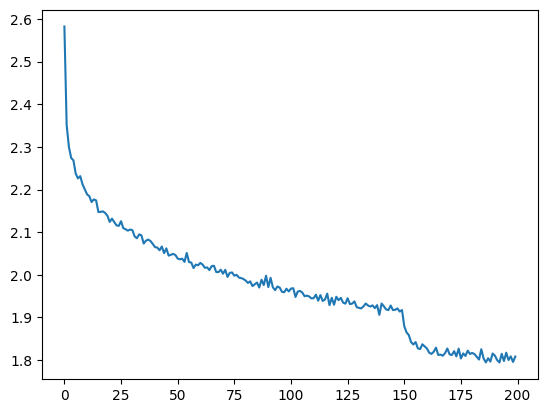

In [121]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [130]:
batch_size, n_embed

(32, 24)

In [137]:
# --- The TensorBoard Solution: nn.Module Wrapper ---
from torch.utils.tensorboard import SummaryWriter

class TensorBoardVisualizer(torch.nn.Module):
    """Temporary wrapper to make custom code compatible with add_graph."""
    def __init__(self, custom_model):
        super().__init__()
        self.custom_model = custom_model
         # Automatically find raw tensors and register them to this nn.Module instance
        for i, layer in enumerate(self.custom_model.layers):
            for j, p in enumerate(layer.parameters()):
                setattr(self, f"layer_{i}_param_{j}", torch.nn.Parameter(p))
            # if hasattr(layer, 'weight') and isinstance(layer.weight, torch.Tensor):
            #     # nn.Parameter links the tensor to the module architecture mapping
            #     setattr(self, f"layer_{i}_weight", torch.nn.Parameter(layer.weight))
            # if hasattr(layer, 'bias') and isinstance(layer.bias, torch.Tensor):
            #     setattr(self, f"layer_{i}_bias", torch.nn.Parameter(layer.bias))

    def forward(self, x):
        return self.custom_model(x)

# 1. Wrap the custom model structure
visualizable_model = TensorBoardVisualizer(model2)

# 2. Log using standard SummaryWriter 
writer = SummaryWriter(log_dir="runs/custom_mlp_experiment")
dummy_input = Xtrain[torch.randint(0, Xtrain.shape[0], (batch_size, ))]

parameters = model2.parameters()
print(f"Number of parametes: {sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad = False

# 3. Add graph tracks the tensor operations through your custom functions
writer.add_graph(visualizable_model, dummy_input)
writer.close()

parameters = model2.parameters()
print(f"Number of parametes: {sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad = True
print("Custom structure successfully traced! Launch TensorBoard with `tensorboard --logdir=runs`")


Number of parametes: 76579
Number of parametes: 76579
Custom structure successfully traced! Launch TensorBoard with `tensorboard --logdir=runs`


/var/folders/kx/jf5lcf41451__wc2mylscgx80000gn/T/ipykernel_38294/410078869.py:116: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if x.shape[1] == 1:


In [139]:
# 1. Load the TensorBoard notebook extension
%load_ext tensorboard

# 2. Launch the dashboard pointing to your log directory
%tensorboard --logdir runs

In [142]:
import torchlens as tl

# Use your existing TensorBoard wrapper model since it exposes nn.Module properties
model_to_view = visualizable_model 

# Run a single inference slice and generate the interactive layer map
model_history = tl.log(model_to_view, dummy_input)


AttributeError: module 'torchlens' has no attribute 'log'